In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive

In [5]:
path = '/content/drive/MyDrive/Data AVD/tourism_dataset_5000 (2).csv'

In [6]:
df = pd.read_csv(path)

In [7]:
df.head(30)

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1000,1.6,3.73,97,4.5,3
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2000,2.6,2.89,90,4.5,3
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,3000,1.7,2.22,94,4.7,3
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,4000,2.0,2.34,92,4.7,3
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,5000,3.7,2.00,96,4.8,4
5,6,50,"['Architecture', 'History', 'Cultural']",4,False,Machu Picchu,"['Great Wall of China', 'Eiffel Tower', 'Colos...",4,6000,2.2,3.74,99,4.5,3
6,7,61,"['Architecture', 'History']",7,False,Eiffel Tower,"['Eiffel Tower', 'Colosseum', 'Taj Mahal']",6,7000,4.1,4.66,93,4.5,4
7,8,23,"['Cultural', 'Architecture']",5,False,Eiffel Tower,['Colosseum'],2,8000,2.8,4.84,91,4.9,3
8,9,34,"['Cultural', 'Art']",5,True,Colosseum,"['Great Wall of China', 'Eiffel Tower', 'Colos...",6,9000,4.0,1.54,95,4.4,4
9,10,61,"['Nature', 'Architecture']",5,False,Colosseum,"['Colosseum', 'Taj Mahal', 'Machu Picchu']",6,10000,3.8,3.59,95,4.7,4


Business Understanding

Dataset ini bertujuan untuk membedah apa yang membuat wisatawan berada di level "puas" atau "cukup" agar pengelola bisa mendongkrak pengalaman mereka menjadi "sangat puas". Dengan menganalisis data rute, durasi, dan penggunaan VR, tujuannya adalah menemukan titik lemah yang masih dianggap biasa saja oleh pengunjung dan memperbaikinya agar layanan wisata di situs bersejarah jadi lebih personal dan berkesan.

1. Business Objective

    Tujuan dari proyek ini adalah meningkatkan kualitas layanan wisata dari sistem rekomendasi supaya wisatawan bisa merasa lebih puas. Dari insight yang ada, kebanyakan wisatawan hanya merasa “cukup puas”, artinya sistem sudah berjalan, tapi belum bisa bikin pengalaman wisata terasa maksimal. Kalau kepuasan wisatawan bisa ditingkatkan, maka peluang wisatawan untuk pakai layanan lagi juga lebih besar, dan citra layanan wisata jadi lebih baik.

2. Assess Situation

    Saat ini sistem punya data yang cukup lengkap tentang wisatawan, seperti minat, durasi tur, rating, kualitas VR, akurasi rekomendasi, dan response time. Tapi hasilnya menunjukkan kepuasan wisatawan masih dominan di level “cukup”. Ini bisa jadi karena rekomendasinya belum sesuai harapan, sistemnya kurang cepat, atau pengalaman VR-nya belum konsisten. Kalau ini dibiarkan, wisatawan bisa bosan dan memilih layanan lain yang lebih memuaskan.


3. Analytic Goals Project Plan

    Tujuan analisisnya adalah mencari tahu faktor apa yang paling bikin wisatawan belum sampai level “sangat puas”. Dari data kita ingin melihat apakah kepuasan dipengaruhi oleh akurasi rekomendasi, response time, kualitas VR, atau faktor lain. Selain itu analisis ini juga bisa dipakai untuk membuat model prediksi kepuasan, supaya sistem bisa tahu wisatawan mana yang berpotensi kurang puas dan bisa diperbaiki dari awal Setelah itu data dibersihkan dan disiapkan supaya gampang dianalisis. Lalu dilakukan analisis hubungan antara kepuasan dengan variabel lain seperti akurasi rekomendasi, kualitas VR, dan response time. Setelah pola ditemukan, dibuat model prediksi kepuasan dan dievaluasi hasilnya dan Terakhir dibuatlah rekomendasi perbaikan sistem supaya kepuasan wisatawan bisa meningkat

#**Check Point 2**

#**Deskripsi Data**

## Informasi lanjutan

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tourist ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Interests                5000 non-null   object 
 3   Preferred Tour Duration  5000 non-null   int64  
 4   Accessibility            5000 non-null   bool   
 5   Site Name                5000 non-null   object 
 6   Sites Visited            5000 non-null   object 
 7   Tour Duration            5000 non-null   int64  
 8   Route ID                 5000 non-null   int64  
 9   Tourist Rating           5000 non-null   float64
 10  System Response Time     5000 non-null   float64
 11  Recommendation Accuracy  5000 non-null   int64  
 12  VR Experience Quality    5000 non-null   float64
 13  Satisfaction             5000 non-null   int64  
dtypes: bool(1), float64(3), 

Tourist ID:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: ID unik setiap wisatawan

Age:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Usia wisatawan

Interests:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Minat atau preferensi wisatawan terhadap jenis wisata tertentu

Preferred Tour Duration:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Durasi tur yang diinginkan oleh wisatawan

Accessibility:
Jumlah baris: 5000
Tipe data: bool
Deskripsi: Kebutuhan aksesibilitas khusus (True/False)

Site Name:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Nama destinasi wisata yang direkomendasikan atau dikunjungi

Sites Visited:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Daftar lokasi wisata yang telah dikunjungi

Tour Duration:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Durasi tur aktual yang dijalani wisatawan

Route ID:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: ID rute perjalanan wisata

Tourist Rating:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Rating yang diberikan wisatawan terhadap pengalaman wisata

System Response Time:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Waktu respon sistem dalam memberikan rekomendasi (dalam satuan tertentu)

Recommendation Accuracy:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Tingkat akurasi sistem dalam memberikan rekomendasi

VR Experience Quality:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Kualitas pengalaman Virtual Reality yang dirasakan wisatawan

Satisfaction:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Tingkat kepuasan wisatawan terhadap keseluruhan pengalaman wisata

### **Informasi Statistik Deskriptif**

In [9]:
df.describe(include='all')

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
count,5000.000000,5000.000000,5000,5000.00000,5000,5000,5000,5000.00000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,85,NaN,2,5,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,['Art'],NaN,False,Great Wall of China,['Eiffel Tower'],NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,353,NaN,2531,1013,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,43.886000,NaN,5.52280,NaN,NaN,NaN,3.97720,2.500500e+06,3.002740,3.238802,92.492200,4.493160,3.534200
std,1443.520003,15.268858,NaN,1.71186,NaN,NaN,NaN,1.99967,1.443520e+06,1.164353,1.016123,4.616081,0.290596,0.736029
min,1.000000,18.000000,NaN,3.00000,NaN,NaN,NaN,1.00000,1.000000e+03,1.000000,1.500000,85.000000,4.000000,3.000000
25%,1250.750000,30.000000,NaN,4.00000,NaN,NaN,NaN,2.00000,1.250750e+06,2.000000,2.360000,88.000000,4.200000,3.000000
50%,2500.500000,44.000000,NaN,6.00000,NaN,NaN,NaN,4.00000,2.500500e+06,3.000000,3.230000,92.000000,4.500000,3.000000
75%,3750.250000,57.000000,NaN,7.00000,NaN,NaN,NaN,5.00000,3.750250e+06,4.000000,4.130000,97.000000,4.700000,4.000000


1. Count (Kelengkapan Data)

Berdasarkan data, total baris adalah 5.000. Maka dapat disimpulkan:

Tidak ada data yang hilang pada setiap kolom (seluruh kolom berisi 5.000 data lengkap).

Kesimpulan: Seluruh kolom tidak mengandung missing values, sehingga dataset sudah lengkap dan siap digunakan untuk analisis lebih lanjut.

2. Mean vs Median (Distribusi Data)
* Kolom Tourist Id

Mean = 2500,5

Median = 2500,5 – Nilai rata-rata sama dengan median

* Kolom Preferred Tour Duration

Mean = 5,52

Median = 6,00 – Nilai rata-rata sedikit lebih rendah dari median

Perbedaan kecil ini menunjukkan distribusi durasi tur yang diinginkan relatif stabil dan tidak dipengaruhi outlier ekstrem.

* Kolom Age

Mean = 43,89

Median = 44,00 – Rata-rata hampir sama dengan median

Ini menandakan distribusi usia wisatawan cukup merata tanpa perbedaan ekstrem.

* Kolom Tour Duration

Mean = 3,98

Median = 4,00 – Perbedaan sangat kecil antara mean dan median

Menunjukkan durasi tur aktual cukup seimbang dan tidak condong ke salah satu sisi.

* Kolom Tourist Rating

Mean = 3,027

Median = 3,00 – Nilai rata-rata lebih tinggi sedikit dari median

Distribusi rating wisatawan tergolong simetris dan stabil.

* Kolom Route ID

Mean = 2,500,000

Median = 2,500,000 – Nilai rata-rata sama dengan median

* Tourist Rating

Mean = 3,00

Median = 3,00 – Nilai rata-rata sama dengan median

* Kolom Recommendation Accuracy

Mean = 92,49

Median = 92,00 – Perbedaan sangat kecil

Menunjukkan performa sistem konsisten tanpa nilai ekstrem yang signifikan.

Kesimpulan:

Secara keseluruhan, data numerik pada dataset ini cenderung berdistribusi normal/simetris dan tidak menunjukkan skewness yang signifikan.

3. Min dan Max (Validasi Logika)
* Preferred Tour Duration

Min = 3

Max = 8

Rentang durasi yang diinginkan masih logis untuk paket wisata (3–8 hari/jam tergantung konteks).

* Age

Min = 18

Max = 70

Menunjukkan variasi usia wisatawan yang luas namun tetap realistis.

* Tour Duration

Min = 1

Max = 9

Durasi aktual masih masuk akal untuk aktivitas wisata.

* Tourist Rating

Min = 1

Max = 5

Rating berada dalam skala normal (1–5), sehingga tidak ada indikasi kesalahan input.

* Recommendation Accuracy

Min = 85

Max = 100

Tingkat akurasi sistem berada pada rentang tinggi dan realistis.

* Satisfaction

Min = 3

Max = 5

Tingkat kepuasan berada pada skala wajar dan menunjukkan mayoritas wisatawan cukup hingga sangat puas.

Kesimpulan:

Semua nilai minimum dan maksimum berada dalam batas logis dan tidak menunjukkan anomali data.

4. Standar Deviasi (std) – Variabilitas Data
* Preferred Tour Duration

Mean = 5,52

Std = 1,71

Menunjukkan variasi preferensi durasi wisata antar wisatawan cukup beragam namun masih terkendali.

* Tour Duration

Mean = 3,98

Std = 2,00

Variasi durasi aktual cukup tinggi, menandakan adanya perbedaan pengalaman perjalanan antar wisatawan.

* Recommendation Accuracy

Mean = 92,49

Std = 4,62

Standar deviasi relatif kecil dibandingkan mean, menunjukkan performa sistem cukup stabil.

* Satisfaction

Mean = 3,53

Std = 0,74

Variasi kepuasan tidak terlalu besar, menandakan mayoritas wisatawan berada di tingkat puas hingga cukup puas.

## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

Dan dapat dilihat dibawah ini, seluruh kolom sudah memiliki tipe data yang sesuai dengan jenis datanya, sehingga tidak perlu dilakukan konversi tipe data.


In [10]:
df.dtypes

,0
Tourist ID,int64
Age,int64
Interests,object
Preferred Tour Duration,int64
Accessibility,bool
Site Name,object
Sites Visited,object
Tour Duration,int64
Route ID,int64
Tourist Rating,float64


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

## **1.Interests**

Secara ejaan, kategori seperti Architecture, Art, History, Cultural, dan Nature sudah konsisten (tidak ada perbedaan huruf besar/kecil atau typo). Sebaiknya dilakukan standarisasi dengan mengurutkan isi list (misalnya secara alfabetis) agar tidak terjadi duplikasi makna dalam analisis data.

In [11]:
print(df['Interests'].unique())

["['Architecture', 'Art', 'History']" "['Cultural', 'Nature']"
 "['History', 'Art', 'Architecture']"
 "['Cultural', 'Art', 'Architecture']" "['Architecture', 'Art']"
 "['Architecture', 'History', 'Cultural']" "['Architecture', 'History']"
 "['Cultural', 'Architecture']" "['Cultural', 'Art']"
 "['Nature', 'Architecture']" "['Cultural']"
 "['Nature', 'Cultural', 'Architecture']"
 "['Cultural', 'Architecture', 'Art']" "['Nature', 'Cultural']"
 "['History']" "['Architecture']" "['Nature', 'History', 'Cultural']"
 "['Nature', 'Art']" "['Nature', 'Art', 'Cultural']" "['Nature']"
 "['Nature', 'History', 'Architecture']" "['Art', 'Nature']" "['Art']"
 "['Art', 'Cultural']" "['History', 'Nature']"
 "['Architecture', 'Nature']" "['Cultural', 'Nature', 'Art']"
 "['Art', 'Architecture']" "['Art', 'Cultural', 'Architecture']"
 "['History', 'Art', 'Nature']" "['History', 'Art', 'Cultural']"
 "['Art', 'Architecture', 'Nature']" "['History', 'Cultural']"
 "['Cultural', 'History', 'Art']"
 "['Cultural'

# **2.Accessibility**

pada kolom accessibility  tidak terdapat incosistent values sehingga data bisa digunakan untuk analisis

In [12]:
print(df['Accessibility'].unique())

[False  True]


# **3.Site Name**

pada kolom ini Terdapat inkonsistensi pada data tersebut, yaitu Jumlah destinasi berbeda (ada yang 4 dan ada yang 5). Format penulisan list tidak menggunakan tanda koma sebagai pemisah.Struktur list belum sepenuhnya seragam.Perlu dilakukan standarisasi format agar konsisten dan mudah dianalisis.

In [13]:
print(df['Site Name'].unique())

['Eiffel Tower' 'Colosseum' 'Machu Picchu' 'Taj Mahal'
 'Great Wall of China']


# **4.Sites Visited**

pada kolom terdapat Penulisan nama destinasi sudah konsisten,Format list sudah benar dan seragam.Namun, urutan destinasi dalam list berbeda-beda sehingga kombinasi yang sama dianggap berbeda.Perlu standarisasi dengan mengurutkan isi list agar tidak terjadi duplikasi data.

In [14]:
print(df['Sites Visited'].unique())

["['Eiffel Tower', 'Great Wall of China', 'Taj Mahal']"
 "['Great Wall of China']" "['Eiffel Tower']"
 "['Machu Picchu', 'Taj Mahal']"
 "['Machu Picchu', 'Taj Mahal', 'Great Wall of China']"
 "['Great Wall of China', 'Eiffel Tower', 'Colosseum']"
 "['Eiffel Tower', 'Colosseum', 'Taj Mahal']" "['Colosseum']"
 "['Colosseum', 'Taj Mahal', 'Machu Picchu']"
 "['Machu Picchu', 'Colosseum', 'Taj Mahal']"
 "['Colosseum', 'Machu Picchu']"
 "['Machu Picchu', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Eiffel Tower']"
 "['Great Wall of China', 'Machu Picchu', 'Colosseum']"
 "['Great Wall of China', 'Machu Picchu']" "['Eiffel Tower', 'Colosseum']"
 "['Colosseum', 'Eiffel Tower', 'Taj Mahal']" "['Taj Mahal']"
 "['Machu Picchu', 'Eiffel Tower', 'Taj Mahal']"
 "['Machu Picchu', 'Great Wall of China']"
 "['Machu Picchu', 'Eiffel Tower']"
 "['Colosseum', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Great Wall of China', 'Eiffel Tower']"
 "['Taj Mahal', 'Great Wall of China']" "

# **5.Route ID**

Pada Kolom Ini dapat disimpulkan bahwa Nilai berbentuk numerik dan berurutan.Rentang data sangat besar (dari 1.000 hingga 5.000.000)
Tidak terlihat inkonsistensi format karena semuanya berupa angka.Sehingga Data sudah konsisten secara tipe dan format, hanya memiliki skala nilai yang besar.

In [15]:
print(df['Route ID'].unique())

[   1000    2000    3000 ... 4998000 4999000 5000000]


### **Missing Values**

Pada tahap ini, kita melihat seberapa banyak data yang hilang pada seluruh kolom. Berdasarkan hasil pengecekan, terlihat bahwa semua kolom memiliki nilai missing sebesar 0%. Hal ini menunjukkan bahwa dataset sudah lengkap dan tidak memerlukan penanganan khusus seperti penghapusan data atau imputasi nilai.

In [16]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Tourist ID,0.0
Age,0.0
Interests,0.0
Preferred Tour Duration,0.0
Accessibility,0.0
Site Name,0.0
Sites Visited,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0


### **Duplicated Values**

Pada tahap ini kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [17]:
df[df.duplicated()]

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun jika ingin menangani anda dapat mengetikkan

df = df.drop_duplicates()

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Berdasarkan hasil yang ditampilkan, semua kolom seperti Tourist ID, Age, Preferred Tour Duration, Tour Duration, Route ID, Tourist Rating, System Response Time, Recommendation Accuracy, VR Experience Quality, dan Satisfaction menunjukkan persentase outliers sebesar 0.0%.

In [18]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Tourist ID,0.0
Age,0.0
Preferred Tour Duration,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0
System Response Time,0.0
Recommendation Accuracy,0.0
VR Experience Quality,0.0
Satisfaction,0.0


# **Eksplorasi Data EDA**

# **Comparison(Perbandingan)**

Aktivitas: Menganalisis distribusi durasi kunjungan pada kolom Tour Duration berdasarkan masing-masing Site Name.

Tujuan: Melihat apakah jumlah kunjungan tersebar merata di setiap destinasi serta mengetahui apakah terdapat perbedaan signifikan antar lokasi wisata.

Visualisasi: Bar chart (diagram batang).

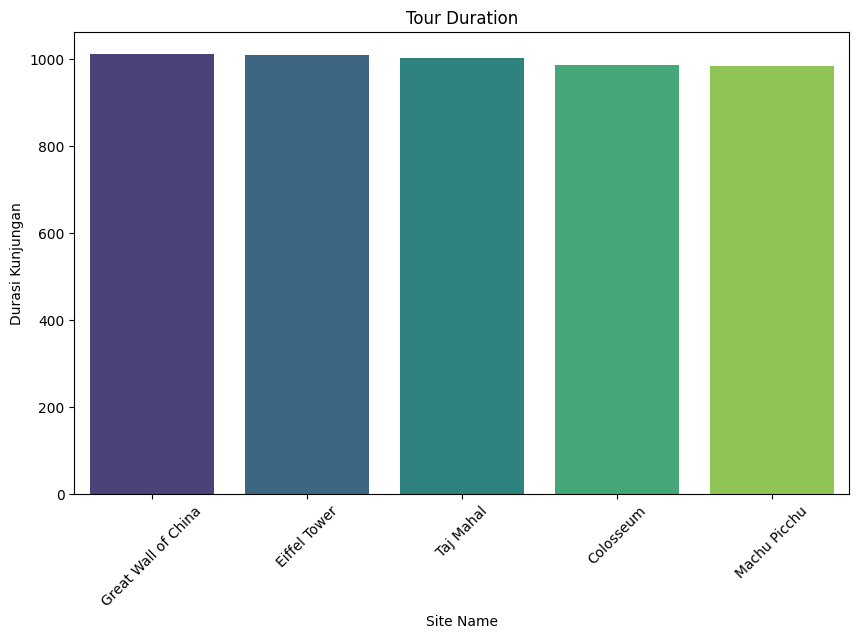

In [19]:
penjualan_market = df.groupby('Site Name')['Tour Duration'].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_market.index, y=penjualan_market.values, palette='viridis', hue=penjualan_market.index, legend=False)
plt.title('Tour Duration')
plt.xlabel('Site Name')
plt.ylabel('Durasi Kunjungan')
plt.xticks(rotation=45)
plt.show()

Insight:

- Jumlah kunjungan pada setiap destinasi relatif merata (sekitar ±1000 data per lokasi).

- Tidak ada destinasi yang sangat dominan atau sangat rendah.

- Dataset tergolong seimbang sehingga perbandingan antar lokasi cukup adil untuk analisis lanjutan.

## **Composition/Komposisi**

Aktivitas: Menganalisis komposisi 3 kategori Interests teratas berdasarkan total Tour Duration.

Tujuan: Mengetahui kategori minat wisatawan mana yang paling dominan serta melihat proporsi kontribusi masing-masing kategori terhadap total durasi kunjungan.

Visualisasi: Pie chart (diagram lingkaran).

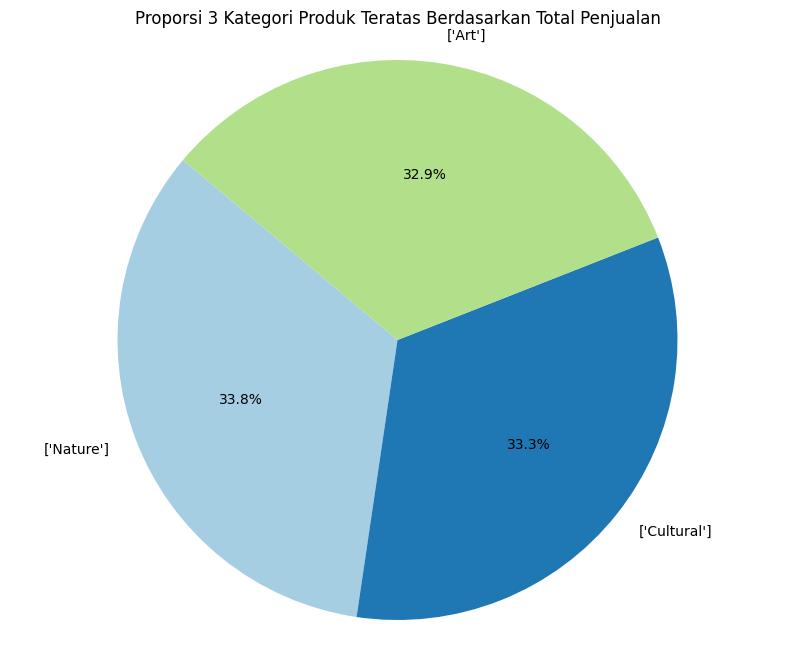

In [20]:
sales_by_category = df.groupby('Interests')['Tour Duration'].sum().sort_values(ascending=False)
sales_by_category_top3 = sales_by_category.head(3)

plt.figure(figsize=(10, 8))
sales_by_category_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 Kategori Produk Teratas Berdasarkan Total Penjualan')
plt.ylabel('')
plt.axis('equal')
plt.show()

Insight:

- Tiga kategori teratas (Nature, Cultural, Art) memiliki proporsi yang hampir sama (sekitar 33% masing-masing).

- Tidak ada satu kategori yang mendominasi secara signifikan.

- Minat wisatawan terhadap jenis wisata cenderung beragam dan seimbang.

## **Distribution/Distribusi**

Aktivitas: Menganalisis distribusi nilai pada kolom Tour Duration untuk melihat pola durasi kunjungan wisatawan.

Tujuan: Mengetahui rentang durasi yang paling sering dipilih wisatawan secara keseluruhan.

Visualisasi: Histogram dengan KDE (Kernel Density Estimation).

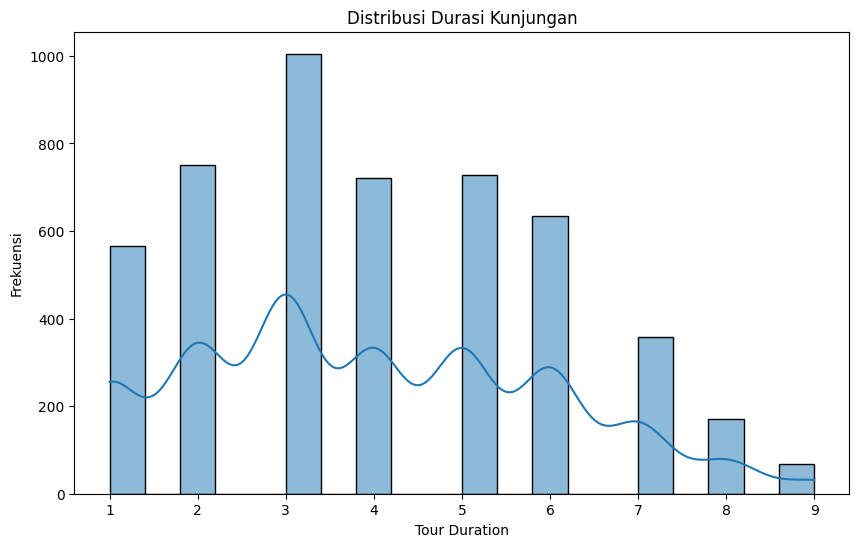

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Tour Duration'], bins=20, kde=True)
plt.title('Distribusi Durasi Kunjungan')
plt.xlabel('Tour Duration')
plt.ylabel('Frekuensi')
plt.show()

Insight:

- Durasi kunjungan paling banyak berada di rentang tengah (sekitar 3–5).

- Durasi sangat tinggi (7–9) memiliki frekuensi lebih rendah.

- Distribusi cenderung sedikit menurun ke kanan (right-skewed ringan), artinya lebih banyak wisatawan memilih durasi sedang dibanding sangat lama.

## **Relationship/Hubungan**

Aktivitas: Menganalisis korelasi antara Tour Duration dengan Umur(Age)

Tujuan: Mengetahui apakah umur wisatawan dapat memengaruhi lamanya durasi kunjungan wisatawan pada tempat wisata

Visualisasi: Heatmap

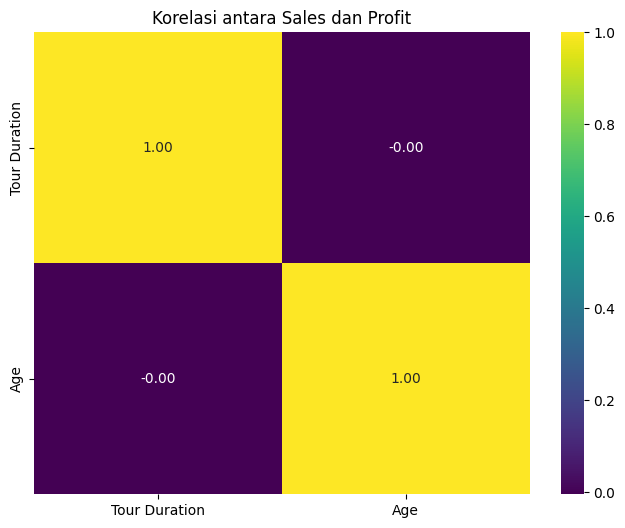

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Tour Duration', 'Age']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Sales dan Profit')
plt.show()

Insight:

Tidak terdapat hubungan yang signifikan antara usia wisatawan dan durasi kunjungan. Artinya, lama kunjungan tidak dipengaruhi oleh faktor umur dalam dataset ini. Kemungkinan ada faktor lain yang lebih berpengaruh, seperti minat (Interests), tingkat kepuasan, atau preferensi durasi.